In [ ]:
# Run this only when you are using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [ ]:
df = pd.read_csv("../data/preprocessed/New_df.csv")   #Change file path as per your directory structure
df.head(10)

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,transf_Age
0,15674932,668,1,2,33,1095,2,1,0,181449.97,0,2.345499
1,15749177,627,1,2,33,365,2,1,1,49503.50,0,2.345499
2,15694510,678,1,2,40,3650,2,1,0,184866.69,0,2.425028
3,15741417,581,1,2,34,730,1,1,1,84560.88,0,2.358088
4,15766172,716,3,2,33,1825,2,1,1,15068.83,0,2.345499
5,15771669,588,2,2,36,1460,1,1,0,136024.31,1,2.381937
6,15692819,593,1,1,30,2920,1,1,0,29792.11,0,2.304681
7,15669611,678,3,2,37,365,1,1,0,106851.60,0,2.393250
8,15691707,676,1,2,43,1460,2,1,0,142917.13,0,2.453966
9,15591721,583,2,2,40,1460,1,1,1,170843.07,0,2.425028


In [ ]:
df.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'transf_Age'],
      dtype='object')

## **1. Univariate Analysis**

### Numerical variables

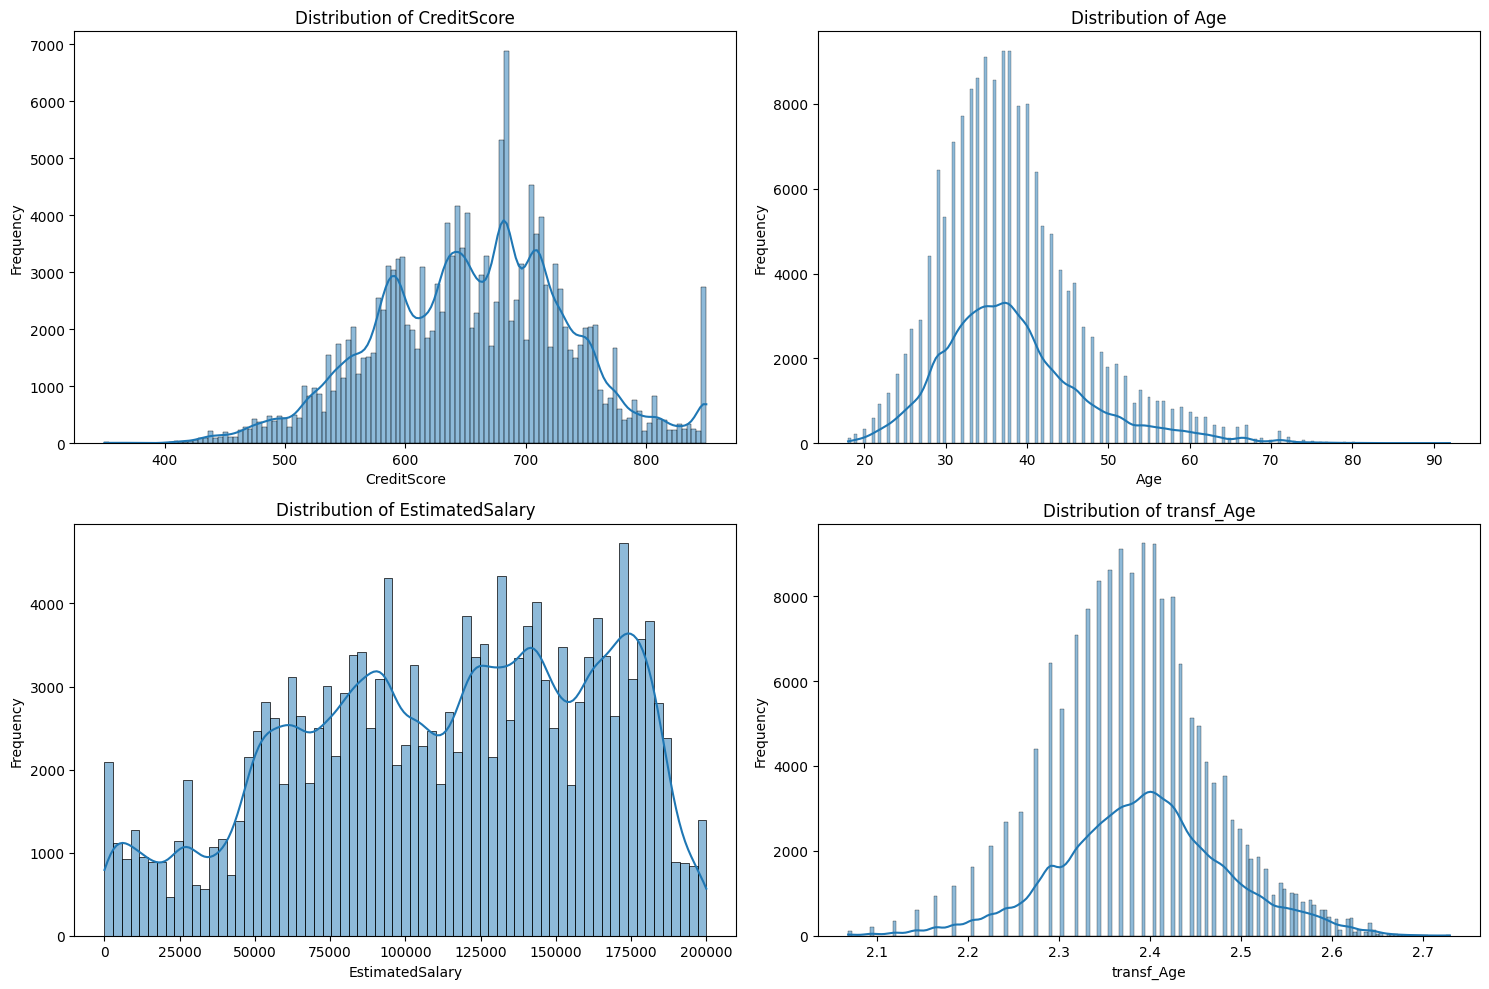

,CreditScore,Age,EstimatedSalary,transf_Age
count,165002.000000,165002.000000,165002.000000,165002.000000
mean,656.457661,38.125405,112575.712332,2.392562
std,80.101454,8.866964,50293.089358,0.091878
min,350.000000,18.000000,11.580000,2.068838
25%,597.000000,32.000000,74637.595000,2.332425
50%,659.000000,37.000000,117948.000000,2.393250
75%,710.000000,42.000000,155152.467500,2.444607
max,850.000000,92.000000,199992.480000,2.729083


In [ ]:
# Bar plot
num_var = ['CreditScore', 'Age', 'EstimatedSalary', 'transf_Age']
plt.figure(figsize=(15, 10))  # Adjust figure size for all subplots
for index, var in enumerate(num_var):
    plt.subplot(2, 2, index + 1)
    sns.histplot(df[var], kde=True) #kde adds a Kernel Density Estimate
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {var}")
plt.tight_layout()
plt.show()

df_num = df[num_var]
df_num.describe()

### Categorical Variables

In [ ]:
df['tenure'] = df['Tenure']/365
df['tenure'] = (df['Tenure']/365).astype(int)

cat_cols = ['Geography', 'Gender', 'tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']

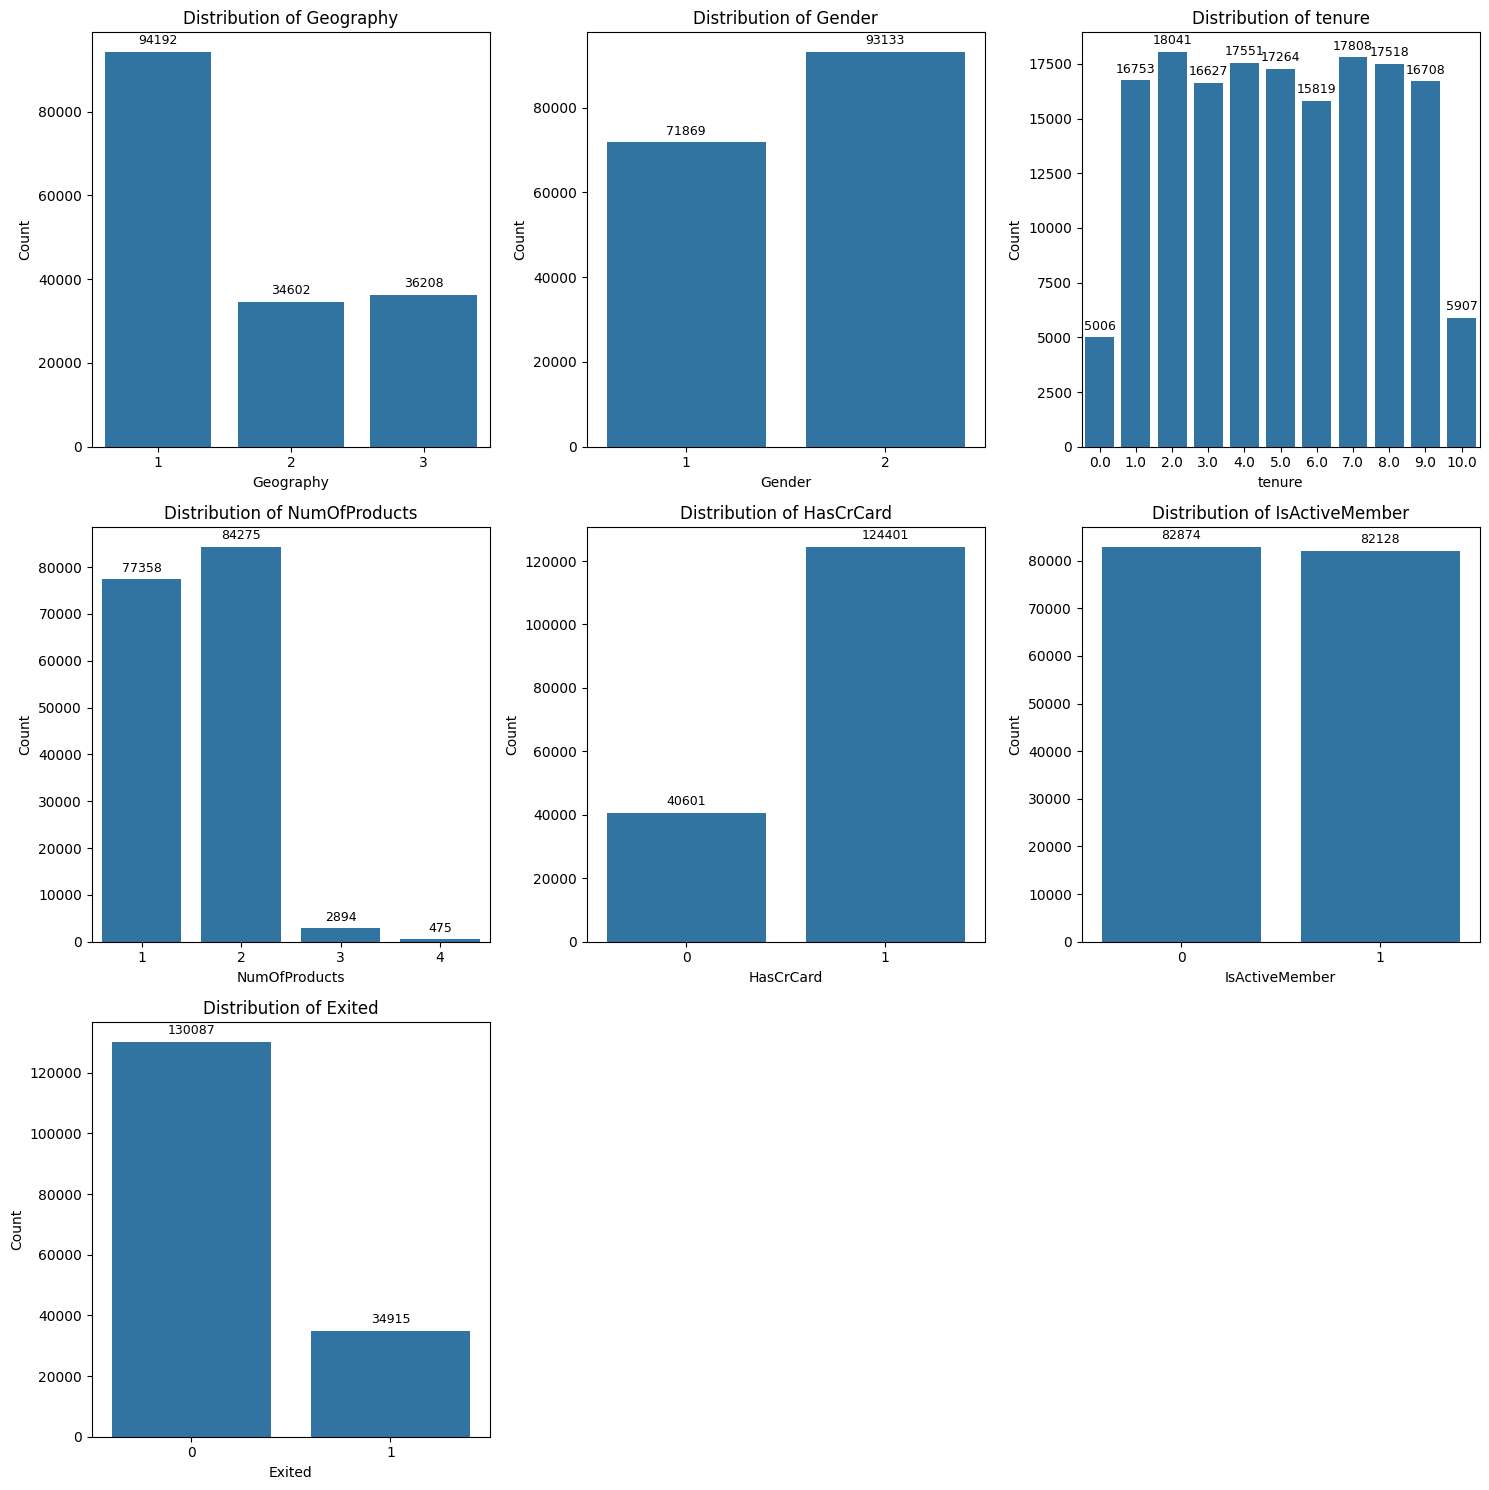

In [ ]:
plt.figure(figsize=(15, 15))  # Adjust the figure size as needed

for i, col in enumerate(cat_cols):
    plt.subplot(3, 3, i + 1)  # Create a 3x3 grid of subplots
    ax = sns.countplot(data=df, x=col)  # Create count plot and store axes object
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    # Add count numbers on top of the bars
    for p in ax.patches:
        height = p.get_height()
        if pd.notna(height):
            ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', xytext=(0, 8), textcoords='offset points',
                        fontsize=9)

plt.tight_layout()  # Adjust subplot parameters to give specified padding
plt.show()

The hypothesis to be tested is:

H0: There is no significant relationship between the categorical variable and churn.

H1: There is a significant relationship between the categorical variable and churn.

In [ ]:
# Checking whether the categorical variable is significantly related to churn
for col in cat_cols:
    contingency_table = pd.crosstab(df[col], df["Exited"])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-Square Test for {col}: p-value = {p}")

Chi-Square Test for Geography: p-value = 0.0
Chi-Square Test for Gender: p-value = 0.0
Chi-Square Test for tenure: p-value = 3.129508151879632e-51
Chi-Square Test for NumOfProducts: p-value = 0.0
Chi-Square Test for HasCrCard: p-value = 2.8978197417288648e-19
Chi-Square Test for IsActiveMember: p-value = 0.0
Chi-Square Test for Exited: p-value = 0.0


As the p-values for all categorical variables are less than the significance threshold of 0.05, we reject H0 at 5% level of significance and conclude that all these variables have a statistically significant relationship with customer churn.

## **2. Bivariate Analysis**

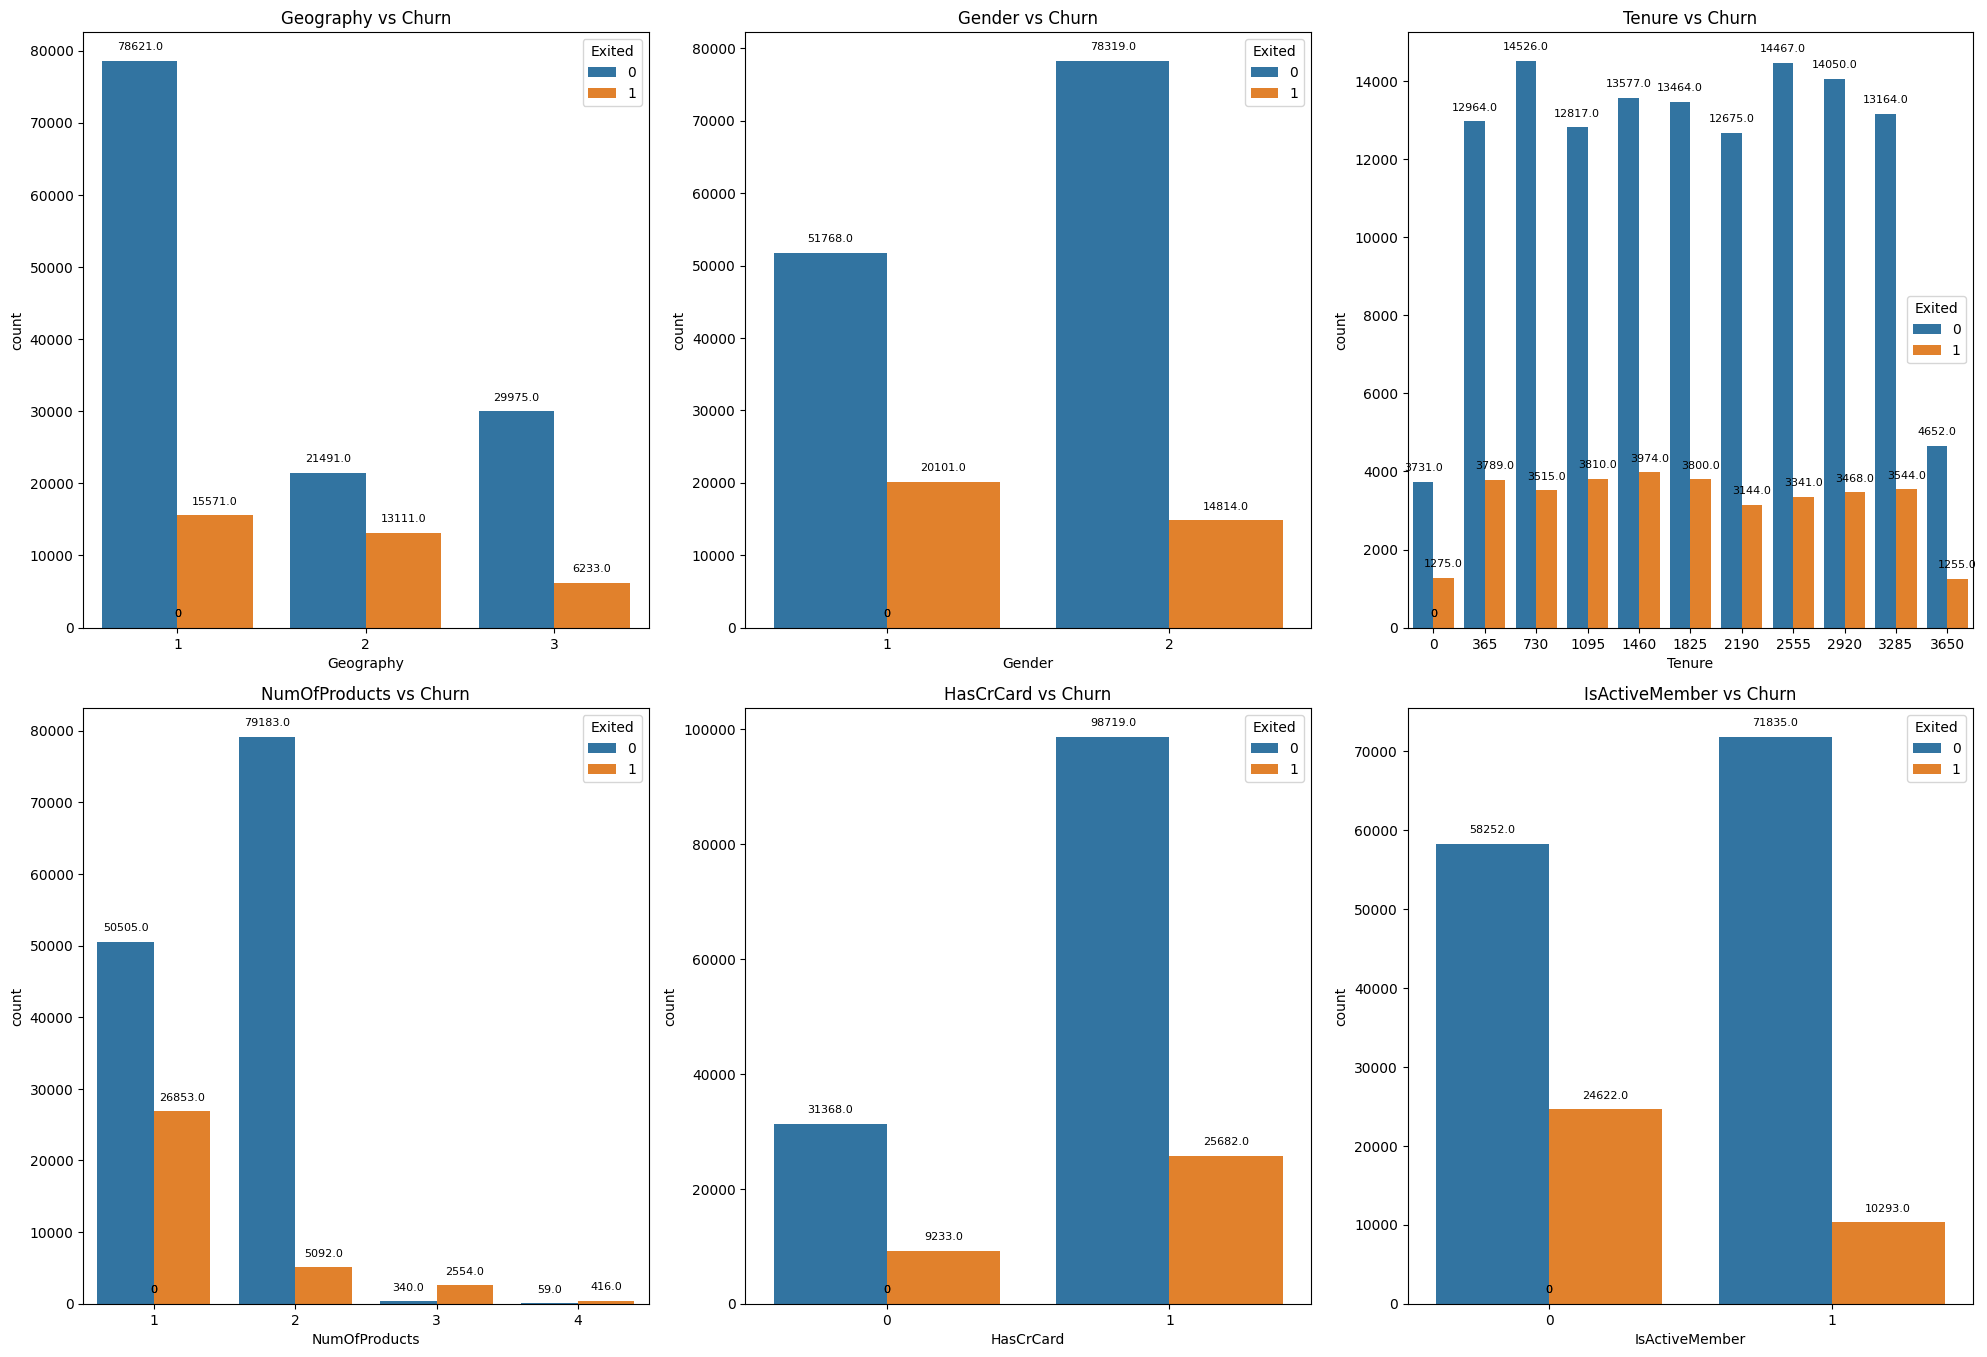

In [ ]:
# Assuming your data is in a DataFrame called 'df'

# List of categorical columns you want to plot
categorical_columns = ['Geography', 'Gender', 'Tenure', 'NumOfProducts',
                       'HasCrCard', 'IsActiveMember']  # Add all your desired categorical columns here

# Create the grouped bar charts
plt.figure(figsize=(20, 20))  # Adjust the figure size as needed
for i, column in enumerate(categorical_columns):
    plt.subplot(3, 3, i + 1)  # Create subplots in a 4x4 grid (adjust as needed)
    ax = sns.countplot(x=column, hue='Exited', data=df)
    plt.title(f'{column} vs Churn')

    # Add count numbers on top of the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                    fontsize=8)

plt.tight_layout()  # Adjust subplot parameters to give specified padding
plt.show()

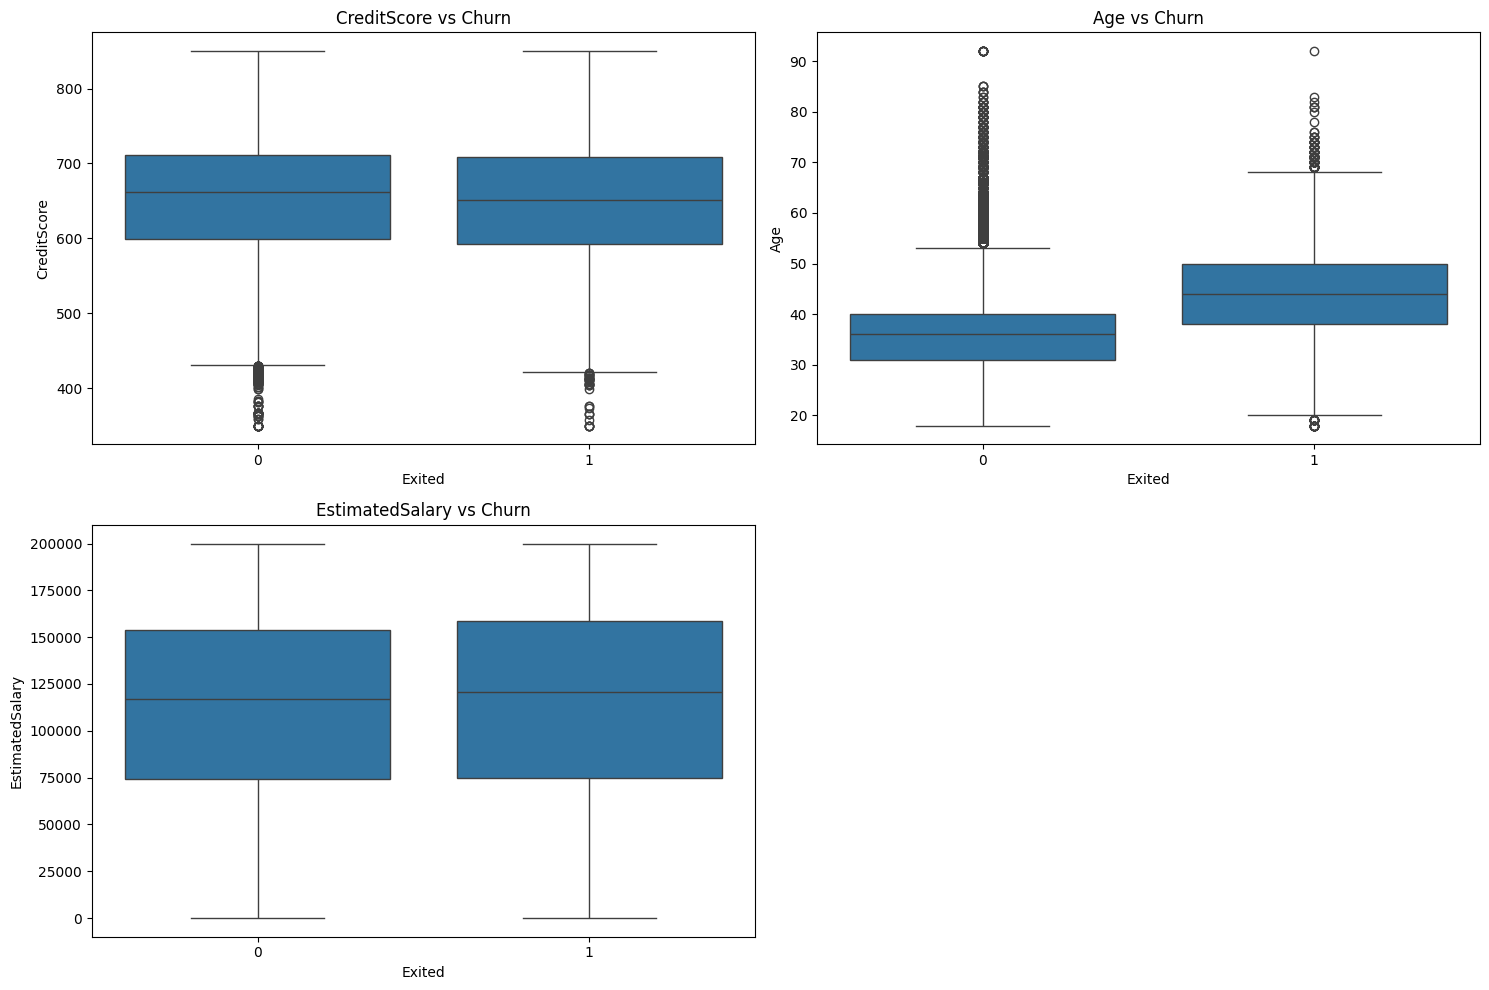

In [ ]:
# Distribution using box pot with respect to churn

columns_to_plot = ['CreditScore', 'Age', 'EstimatedSalary']

plt.figure(figsize=(15, 10))  # Adjust the figure size as needed

for i, column in enumerate(columns_to_plot):
    plt.subplot(2, 2, i + 1)  # Create subplots in a 2x3 grid
    sns.boxplot(x='Exited', y=df[column], data=df)  # Add 'Is_customer_exited' to the x-axis
    plt.title(f'{column} vs Churn')
    plt.ylabel(column)

plt.tight_layout()  # Adjust subplot parameters to give specified padding
plt.show()

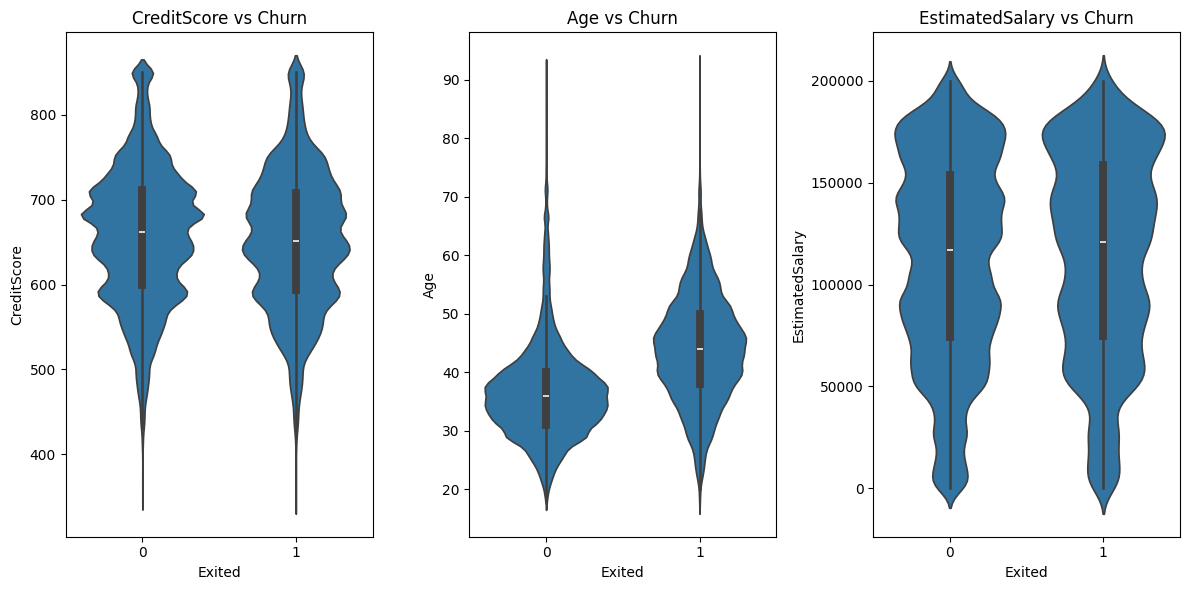

In [ ]:
# Distribution using violin plot with respect to churn

num_cols = ['CreditScore', 'Age', 'EstimatedSalary']

plt.figure(figsize=(12, 6))  # Adjust the figure size as needed

for i, column in enumerate(num_cols):
    plt.subplot(1, 3, i + 1)  # Create subplots in a 2x3 grid
    sns.violinplot(x='Exited', y=df[column], data=df)  # Add 'Is_customer_exited' to the x-axis
    plt.title(f'{column} vs Churn')
    plt.ylabel(column)

plt.tight_layout()  # Adjust subplot parameters to give specified padding
plt.show()

## **3. Correlation Analysis**

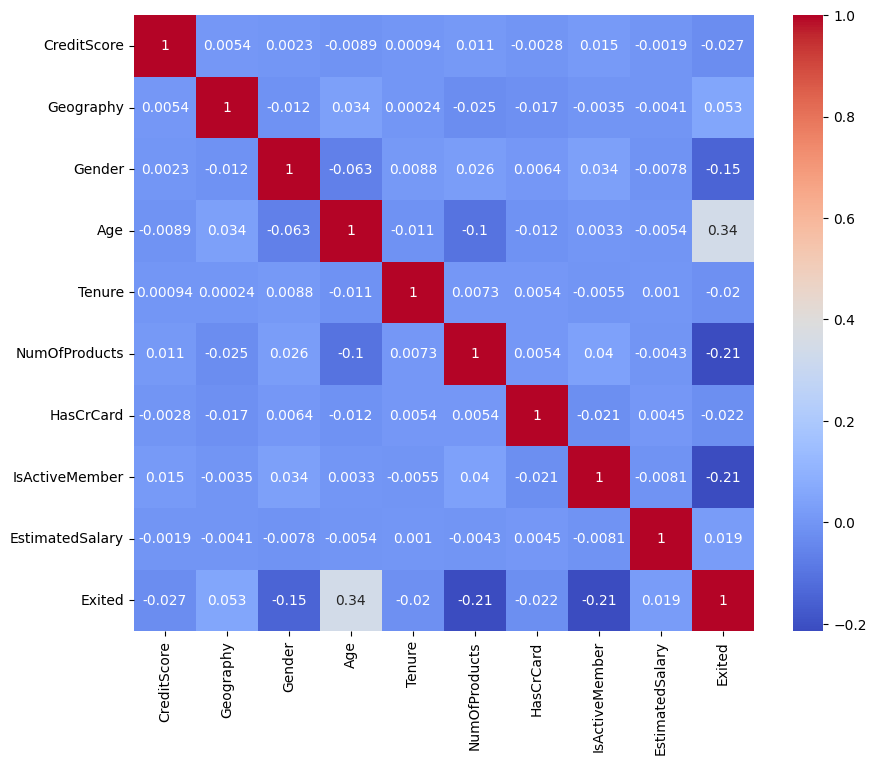

In [ ]:
# Correlation analysis
cols = ['CustomerId', 'transf_Age']
df1 = df.drop(cols, axis=1)

df1 = pd.DataFrame(df1)
corr = df1.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
corr

,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,0.005371,0.002311,-0.008881,0.000940,0.011365,-0.002820,0.014800,-0.001861,-0.027425
Geography,0.005371,1.000000,-0.012046,0.034165,0.000240,-0.025105,-0.016710,-0.003475,-0.004123,0.053270
Gender,0.002311,-0.012046,1.000000,-0.063145,0.008798,0.026090,0.006432,0.033761,-0.007826,-0.146434
Age,-0.008881,0.034165,-0.063145,1.000000,-0.010758,-0.102167,-0.012152,0.003283,-0.005442,0.340825
Tenure,0.000940,0.000240,0.008798,-0.010758,1.000000,0.007328,0.005366,-0.005487,0.001028,-0.019594
NumOfProducts,0.011365,-0.025105,0.026090,-0.102167,0.007328,1.000000,0.005449,0.039738,-0.004289,-0.214538
HasCrCard,-0.002820,-0.016710,0.006432,-0.012152,0.005366,0.005449,1.000000,-0.021058,0.004462,-0.022106
IsActiveMember,0.014800,-0.003475,0.033761,0.003283,-0.005487,0.039738,-0.021058,1.000000,-0.008057,-0.210274
EstimatedSalary,-0.001861,-0.004123,-0.007826,-0.005442,0.001028,-0.004289,0.004462,-0.008057,1.000000,0.018827
Exited,-0.027425,0.053270,-0.146434,0.340825,-0.019594,-0.214538,-0.022106,-0.210274,0.018827,1.000000
